<a href="https://colab.research.google.com/github/aasimusman1212-cyber/basics-of-ml/blob/main/deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# step 1 : install and import tensor flow
!pip install tensorflow
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [3]:


#2. loading the MNIST data
(x_train, y_train), (x_test, y_test) = (
    tf.keras.datasets.mnist.load_data()
)

print("training images :", x_train.shape)
print("training lables :", y_train.shape)
print("test images :", x_test.shape)
print("test lables :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
training images : (60000, 28, 28)
training lables : (60000,)
test images : (10000, 28, 28)
test lables : (10000,)


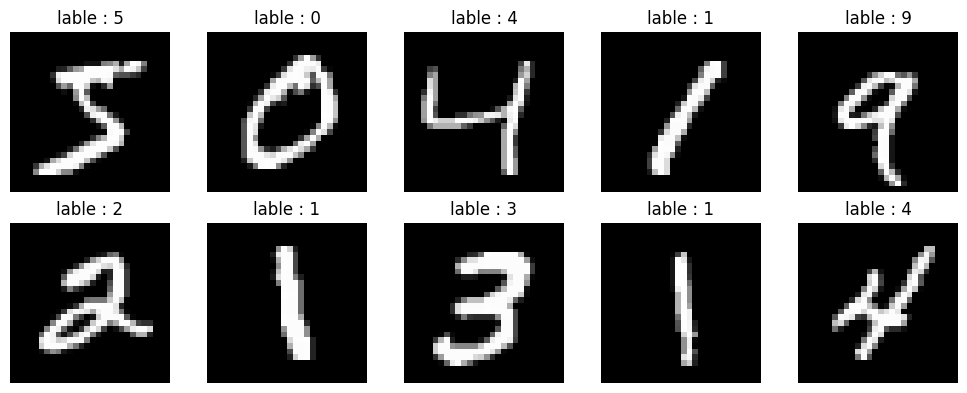

In [4]:
#displaying the sample images
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"lable : {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
# preprocessing
#pixel values range from 0 to 255
x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0
print("minimum pixel value:",x_train.min())
print("maximum pixel value:",x_train.max())

minimum pixel value: 0.0
maximum pixel value: 1.0


In [6]:
#designing the model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),
    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),
    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
#compilation
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.1
)
model.compile(
    optimizer=optimizer,
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("model compiled successfully...")

model compiled successfully...


In [8]:
#evaluation of untrained model
initial_loss , initial_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)
print("before training")
print("test loss : ",initial_loss)
print("test accuracy :", initial_accuracy)

before training
test loss :  2.432992458343506
test accuracy : 0.08460000157356262


In [9]:
#training the model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8618 - loss: 0.4821 - val_accuracy: 0.9337 - val_loss: 0.2289
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9332 - loss: 0.2297 - val_accuracy: 0.9555 - val_loss: 0.1618
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9510 - loss: 0.1711 - val_accuracy: 0.9632 - val_loss: 0.1302
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9605 - loss: 0.1373 - val_accuracy: 0.9703 - val_loss: 0.1073
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9669 - loss: 0.1143 - val_accuracy: 0.9727 - val_loss: 0.0964
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9715 - loss: 0.0963 - val_accuracy: 0.9757 - val_loss: 0.0911
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9756 - loss: 0.0841 - val_accuracy: 0.9730 - val_loss: 0.0914
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9791 - loss: 0.0736 - val_accuracy: 0.

In [10]:
final_loss ,final_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)
print("before training")
print("test loss : ",final_loss)
print("test accuracy :", final_accuracy)

before training
test loss :  0.08422894030809402
test accuracy : 0.9729999899864197


NameError: name 'predicted_lables' is not defined

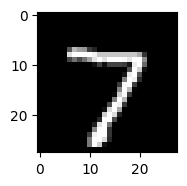

In [12]:
plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[i], cmap="gray")
  predicted = predicted_lables[i]
  actual= y_test[i]
  confidence = probabilities[i][predicted]
  plt.title(
      f"actual:{actual}\n"
      f"predicted:{predicted}\n"
      f"confidence:{confidence:.2f}"
  )
  plt.axis("off")
plt.tight_layout()
plt.show()
